## 🧠 Sinhala Sentiment Analysis Model Training using BiLSTM

This notebook covers:
- Loading preprocessed datasets
- Tokenizer and label encoder loading
- Building Embedding + BiLSTM model
- Model training
- Evaluation
- Saving trained model

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt


### Load Preprocessed Dataset

In [2]:
train_df = pd.read_csv(
    "../data/preprocessed/train_preprocessed.csv"
)

test_df = pd.read_csv(
    "../data/preprocessed/test_preprocessed.csv"
)

print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

Train Dataset Shape: (6988, 4)
Test Dataset Shape: (1743, 4)


### Load Tokenizer and Encoder

In [3]:
with open(
    "../models/tokenizer.pkl",
    "rb"
) as file:
    tokenizer = pickle.load(file)

with open(
    "../models/label_encoder.pkl",
    "rb"
) as file:
    label_encoder = pickle.load(file)

### 🎯 Prepare Features and Labels

In [4]:

X_train = train_df["clean_text"]
X_test = test_df["clean_text"]

y_train = train_df["encoded_label"]
y_test = test_df["encoded_label"]

### 🔢 Convert Text into Sequences

In [5]:
X_train = tokenizer.texts_to_sequences(X_train)

X_test = tokenizer.texts_to_sequences(X_test)

### 📏 Padding Sequences

Ensure all sequences have the same length.

In [6]:
MAX_LENGTH = 100

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post"
)

### 📦 Final Dataset Shapes

In [7]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (6988, 100)
X_test Shape: (1743, 100)
y_train Shape: (6988,)
y_test Shape: (1743,)


### 🏗️ Build Embedding + BiLSTM Model

Model Architecture:
- Embedding Layer
- Bidirectional LSTM
- Dropout
- Dense Layers
- Softmax Output

### Create BiLSTM Model

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    Input,
    SpatialDropout1D
)

MAX_WORDS = len(tokenizer.word_index) + 1
EMBEDDING_DIM = 256
MAX_LENGTH = 100

model = Sequential([

    Input(shape=(MAX_LENGTH,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    SpatialDropout1D(0.3),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    ),

    Bidirectional(
        LSTM(
            64,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    ),

    BatchNormalization(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(3, activation='softmax')
])

### Compile Model

In [22]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

optimizer = Adam(learning_rate=0.0003)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    ),

    ModelCheckpoint(
        'best_model.keras',
        save_best_only=True
    )
]

### Model Summary

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 100, 256)            │       6,450,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 100, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 100, 256)            │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,034,499 (26.83 MB)

 Trainable params: 7,034,243 (26.83 MB)

 Non-trainable params: 256 (1.00 KB)

### Add EarlyStopping

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True
)

### Class Weights

In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(1.1514252759927501), 1: np.float64(0.7167179487179487), 2: np.float64(1.35821185617104)}


### Train Model

In [26]:
EPOCHS = 15
BATCH_SIZE = 32

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 171s 767ms/step - accuracy: 0.3766 - loss: 1.1045 - val_accuracy: 0.5064 - val_loss: 1.0917
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 139s 751ms/step - accuracy: 0.4826 - loss: 0.9468 - val_accuracy: 0.5107 - val_loss: 1.0321
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 141s 744ms/step - accuracy: 0.5873 - loss: 0.7725 - val_accuracy: 0.5815 - val_loss: 0.9167
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 144s 753ms/step - accuracy: 0.6916 - loss: 0.6088 - val_accuracy: 0.5737 - val_loss: 0.8578
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 144s 766ms/step - accuracy: 0.7755 - loss: 0.5004 - val_accuracy: 0.5708 - val_loss: 0.9020


### 📊 Evaluate Model

In [27]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.6271 - loss: 0.8470
Test Loss: 0.8470
Test Accuracy: 0.6271


### 📈 Training Accuracy Graph

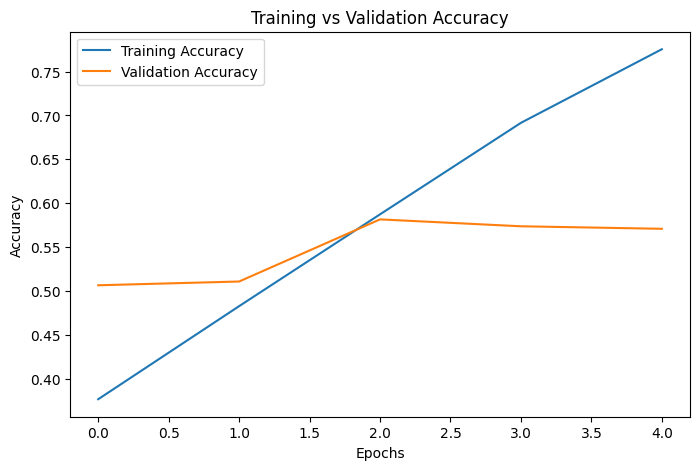

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

### 🔮 Generate Predictions

In [29]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

55/55 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step


### 📑 Classification Report

In [30]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.52      0.25      0.33       435
           1       0.58      0.75      0.65       731
           2       0.74      0.76      0.75       577

    accuracy                           0.63      1743
   macro avg       0.61      0.59      0.58      1743
weighted avg       0.62      0.63      0.61      1743



### 📊 Confusion Matrix

Visualize model prediction performance using a confusion matrix.

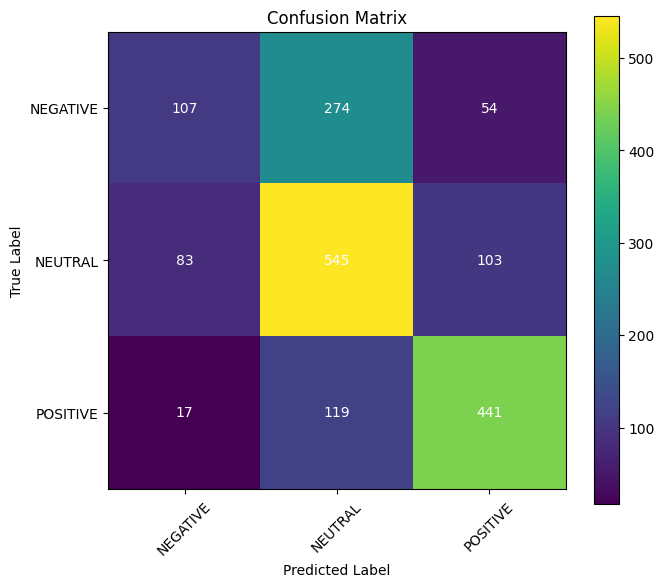

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(
    y_test,
    y_pred
)

# ============================================
# Plot Confusion Matrix
# ============================================

labels = label_encoder.classes_

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(labels))

plt.xticks(
    tick_marks,
    labels,
    rotation=45
)

plt.yticks(
    tick_marks,
    labels
)

# Add values inside cells
for i in range(len(labels)):
    for j in range(len(labels)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

### 💾 Save Trained BiLSTM Model

In [32]:
model.save(
    "../models/bilstm_sentiment_model.keras"
)

### ✅ Model Training Completed

The Sinhala sentiment analysis model is now ready for:
- real-time prediction
- Streamlit deployment